# Hackathon baseline: modelo base + auditoría de correlación

Este notebook asume que existen dos archivos en el entorno de Colab:

- `train_updated.csv`
- `test_updated.csv`

Objetivos:

1. Cargar y auditar el dataset.
2. Entrenar un **modelo base** usando todas las variables.
3. Evaluar el modelo base.
4. Analizar **correlación / asociación** entre variables y target para detectar señales de leakage.
5. Generar un ranking de variables sospechosas.
6. Entrenar un modelo auditado excluyendo variables sospechosas seleccionadas manualmente.

> Este notebook **no necesita conocer de antemano** cuáles son las 2 variables con leakage ni cuál es la irrelevante.


In [5]:
# ============================================================
# 1. Librerías
# ============================================================
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

In [15]:
# ============================================================
# 2. Cargar datos
# ============================================================
TRAIN_PATH = "train_updated.csv"
TEST_PATH = "test_updated.csv"


train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (39073, 18)
Test shape : (9769, 18)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,United-States,Private,HS-grad,9,77253,White,0,Never-married,71,priority_low,C91,Not-in-family,17,0,0,Handlers-cleaners,Male,0
1,United-States,Private,10th,6,329783,White,0,Never-married,17,priority_low,B03,Other-relative,10,0,0,Sales,Female,0
2,El-Salvador,Private,HS-grad,9,91257,White,0,Married-civ-spouse,27,priority_high,B03,Husband,40,0,0,Other-service,Male,0
3,United-States,Private,HS-grad,9,125577,Black,0,Separated,43,priority_low,D12,Unmarried,40,0,0,Adm-clerical,Female,0
4,United-States,Private,Bachelors,13,137978,White,0,Married-civ-spouse,31,priority_high,B03,Husband,40,0,0,Exec-managerial,Male,0


In [7]:
# ============================================================
# 3. Detectar columna target
# ============================================================
target_col = "X18"
print("Target detectado:", target_col)
print(train_df[target_col].value_counts(dropna=False))

Target detectado: X18
X18
0    29724
1     9349
Name: count, dtype: int64


---
## EDA — Análisis Exploratorio de Datos

Las siguientes celdas siguen un proceso sistemático de exploración en 5 fases:

1. **Familiarización** — estructura, tipos, valores faltantes
2. **Distribuciones** — histogramas y tasas de positivos por categoría
3. **Relaciones** — estadísticos por clase, boxplots, correlación
4. **Anomalías** — outliers, alta cardinalidad, variables casi constantes
5. **Insights** — ranking preliminar de sospecha para la auditoría de leakage

---


### Fase 1 — Familiarización con los datos


In [16]:
# ============================================================
# EDA-1. Perfil general del dataset
# ============================================================
print(f"Train: {train_df.shape[0]:,} filas  x  {train_df.shape[1]} columnas")
print(f"Test : {test_df.shape[0]:,} filas  x  {test_df.shape[1]} columnas")

eda_numeric = train_df.select_dtypes(include="number").columns.drop(target_col).tolist()
eda_categoric = train_df.select_dtypes(include="object").columns.tolist()

print(f"\nVariables numericas   ({len(eda_numeric)}): {eda_numeric}")
print(f"Variables categoricas ({len(eda_categoric)}): {eda_categoric}")
print(f"Target: {target_col}")

Train: 39,073 filas  x  18 columnas
Test : 9,769 filas  x  18 columnas

Variables numericas   (7): ['X4', 'X5', 'X7', 'X9', 'X13', 'X14', 'X15']
Variables categoricas (10): ['X1', 'X2', 'X3', 'X6', 'X8', 'X10', 'X11', 'X12', 'X16', 'X17']
Target: X18


In [17]:
# ============================================================
# EDA-2. Valores faltantes y cardinalidad
# ============================================================
cols_feat = [c for c in train_df.columns if c != target_col]
profile = pd.DataFrame(
    {
        "dtype": train_df[cols_feat].dtypes.astype(str),
        "n_missing": train_df[cols_feat].isnull().sum(),
        "pct_missing": (train_df[cols_feat].isnull().mean() * 100).round(2),
        "n_unique": train_df[cols_feat].nunique(),
        "example": [
            (
                str(train_df[c].dropna().iloc[0])
                if train_df[c].dropna().shape[0] > 0
                else "NaN"
            )
            for c in cols_feat
        ],
    }
).sort_values(["dtype", "n_unique"])

display(profile)

,dtype,n_missing,pct_missing,n_unique,example
X15,int64,0,0.00,2,0
X4,int64,0,0.00,16,9
X9,int64,0,0.00,73,71
X13,int64,0,0.00,95,17
X14,int64,0,0.00,99,0
X7,int64,0,0.00,122,0
X5,int64,0,0.00,24612,77253
X10,str,0,0.00,2,priority_low
X17,str,0,0.00,2,Male
X11,str,0,0.00,4,C91


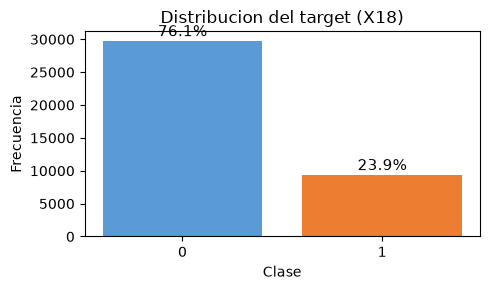

Ratio desbalance  ->  clase 0: 76.1%  |  clase 1: 23.9%
Implication: baseline ingenuo (predecir siempre 0) alcanza 76.1% accuracy.


In [12]:
# ============================================================
# EDA-3. Balance del target
# ============================================================
target_counts = train_df[target_col].value_counts()
target_pct = train_df[target_col].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(
    target_counts.index.astype(str), target_counts.values, color=["#5B9BD5", "#ED7D31"]
)
for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct}%",
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax.set_title(f"Distribucion del target ({target_col})")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Ratio desbalance  ->  clase 0: {target_pct[0]}%  |  clase 1: {target_pct[1]}%")
print(
    f"Implication: baseline ingenuo (predecir siempre 0) alcanza {target_pct[0]}% accuracy."
)

### Fase 2 — Distribuciones por variable


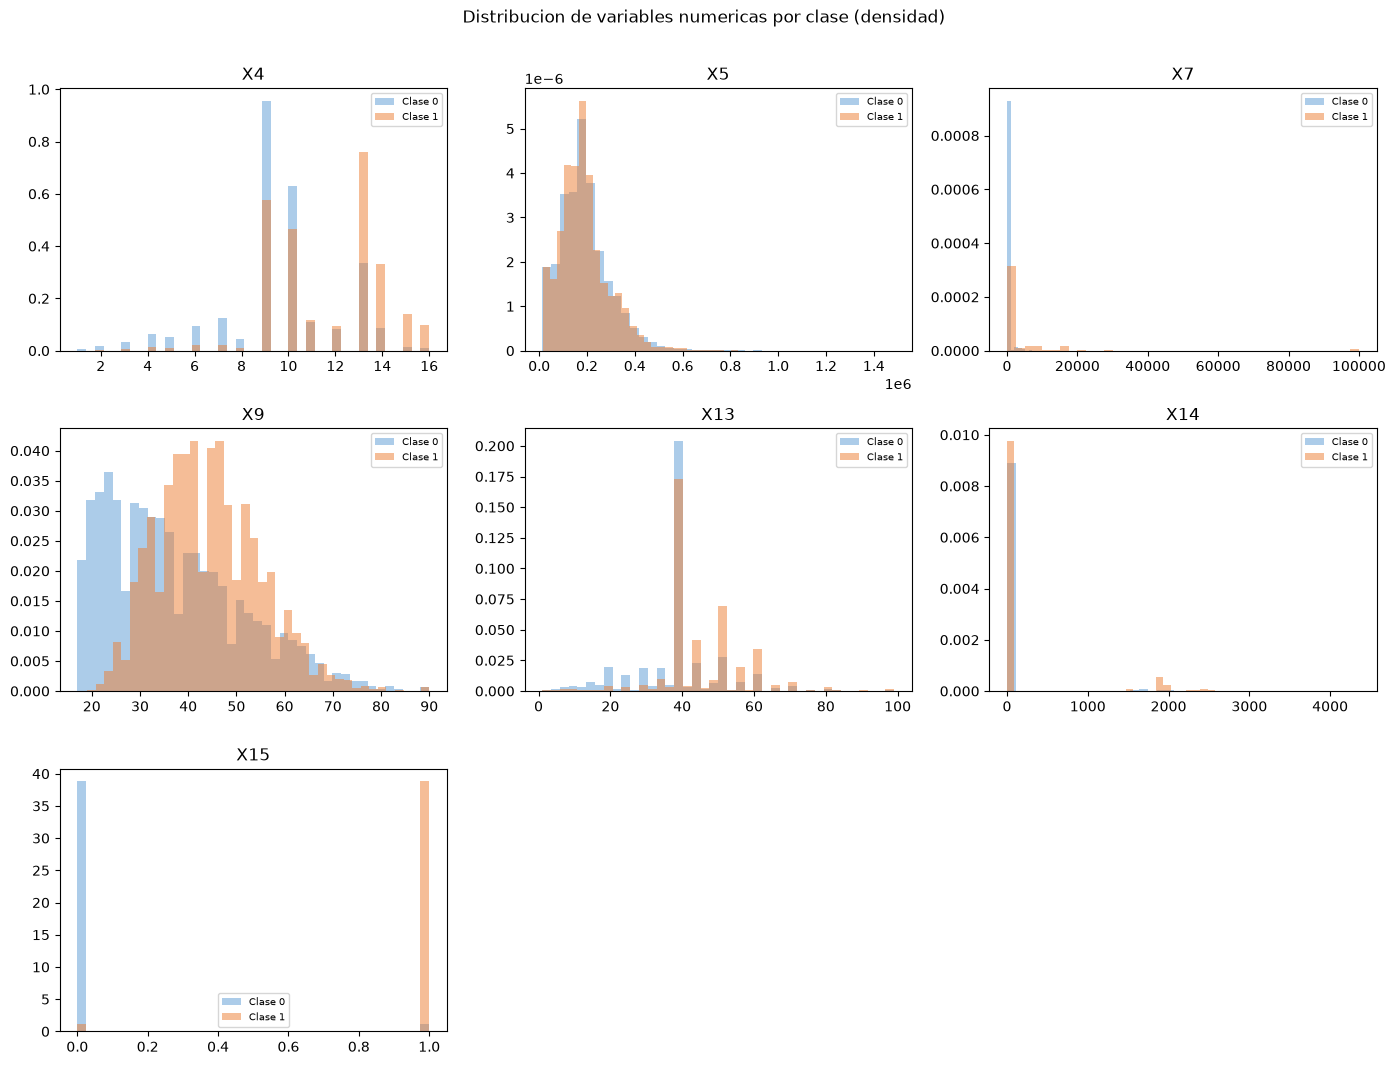

In [13]:
# ============================================================
# EDA-4. Histogramas de variables numericas por clase
# ============================================================
n_num = len(eda_numeric)
ncols = 3
nrows = (n_num + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(eda_numeric):
    ax = axes[i]
    for cls, color, lbl in [(0, "#5B9BD5", "Clase 0"), (1, "#ED7D31", "Clase 1")]:
        subset = train_df[train_df[target_col] == cls][col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=lbl, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribucion de variables numericas por clase (densidad)", y=1.01)
plt.tight_layout()
plt.show()

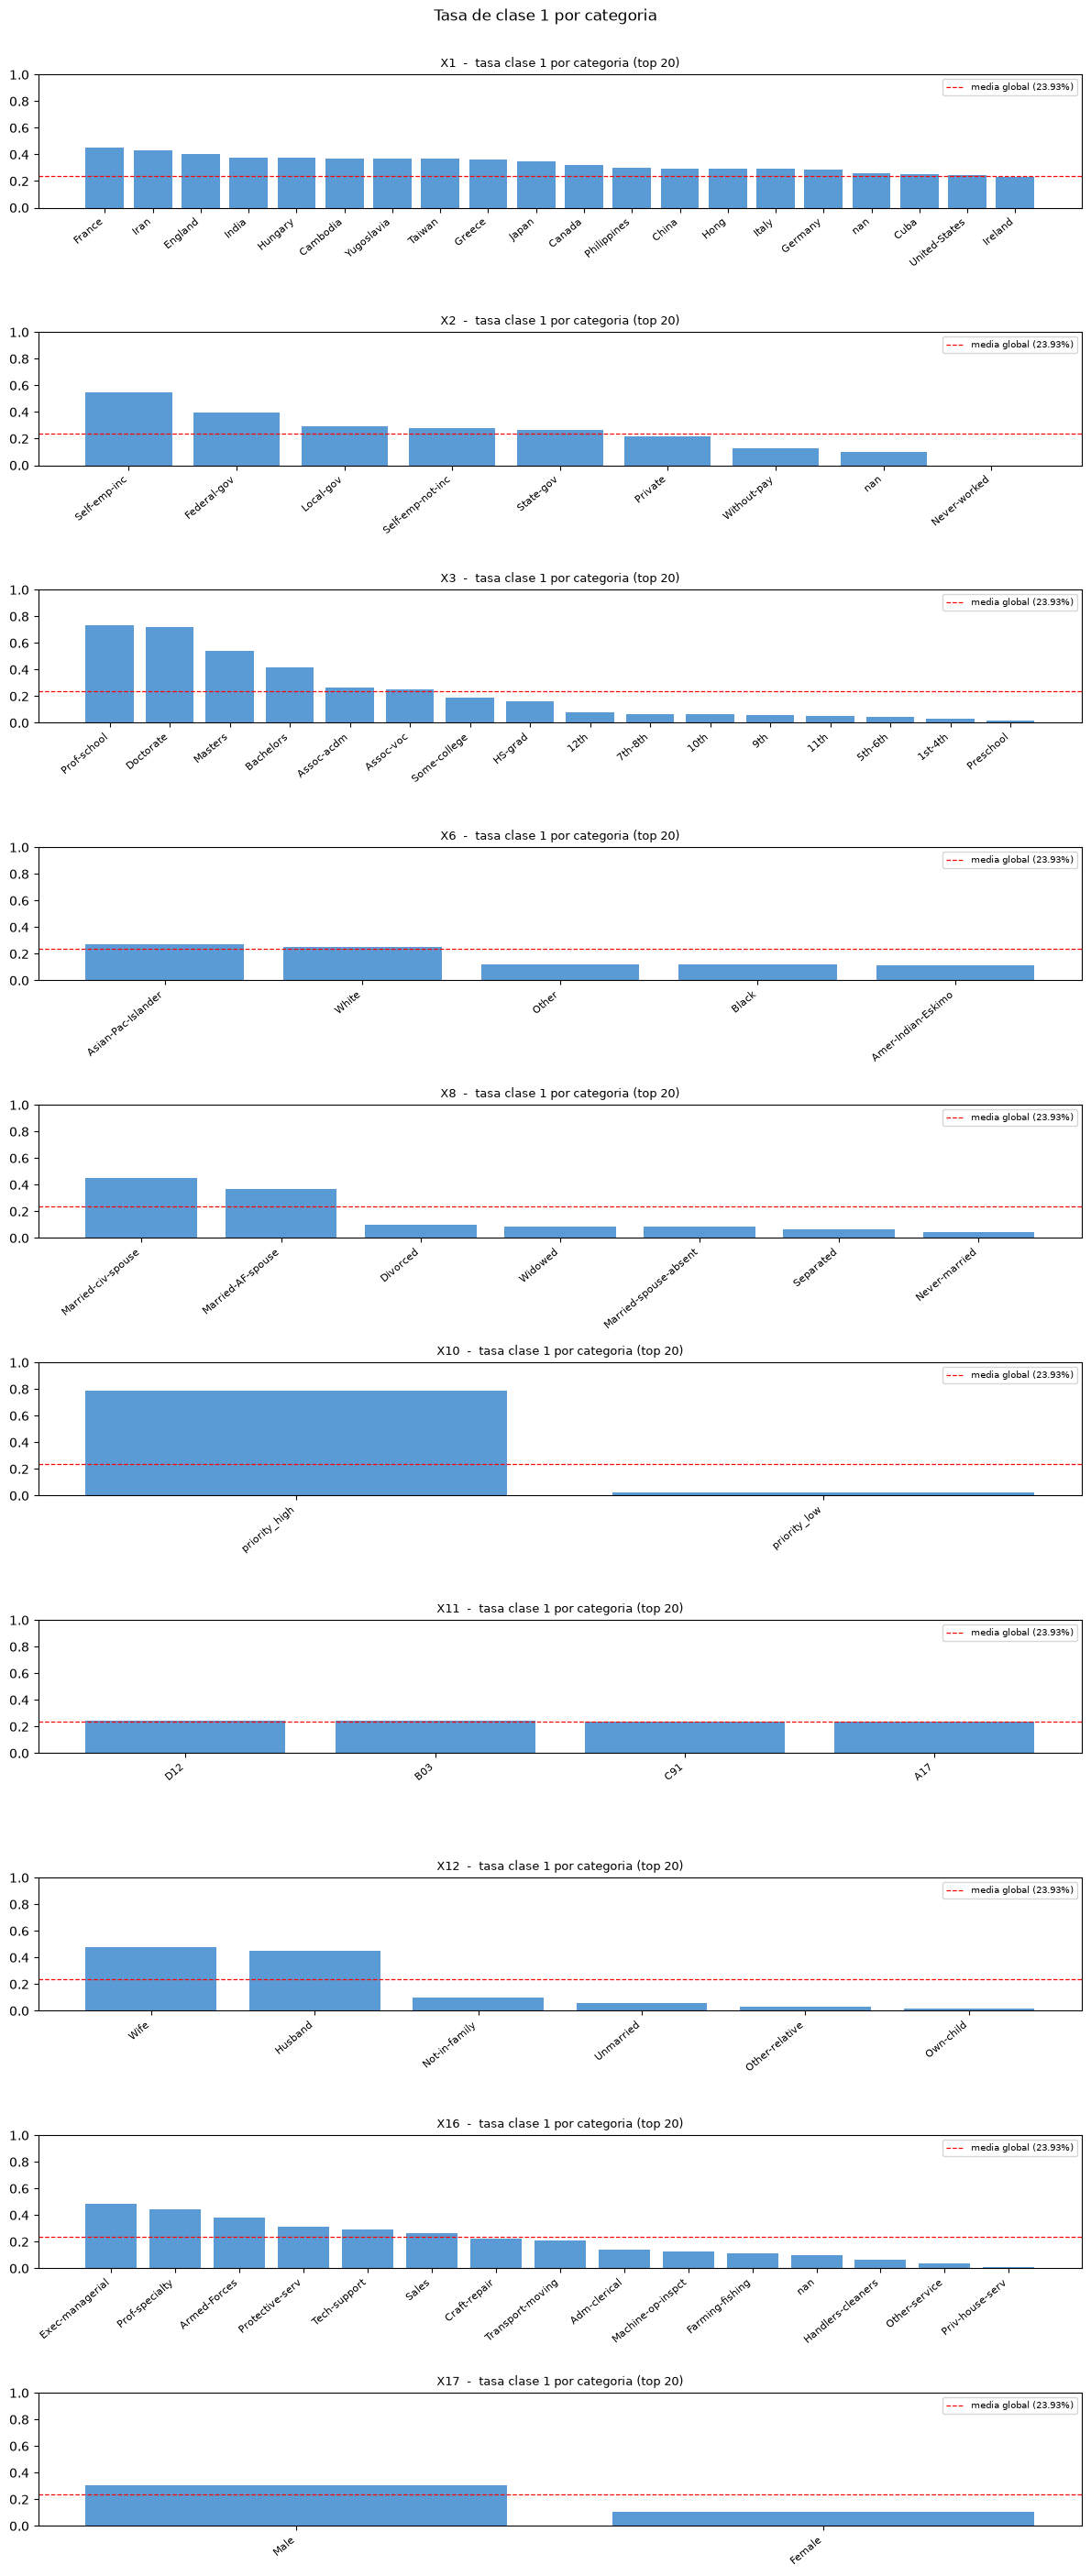

In [14]:
# ============================================================
# EDA-5. Tasa de positivos por variable categorica
# ============================================================
global_rate = train_df[target_col].mean()
n_cat = len(eda_categoric)

fig, axes = plt.subplots(n_cat, 1, figsize=(12, n_cat * 2.8))
if n_cat == 1:
    axes = [axes]

for ax, col in zip(axes, eda_categoric):
    grp = (
        train_df.groupby(col, dropna=False)[target_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "tasa_positivo", "count": "n"})
        .sort_values("tasa_positivo", ascending=False)
        .head(20)
    )
    ax.bar(range(len(grp)), grp["tasa_positivo"], color="#5B9BD5")
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp.index.astype(str), rotation=40, ha="right", fontsize=8)
    ax.set_title(f"{col}  -  tasa clase 1 por categoria (top 20)", fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(
        global_rate,
        color="red",
        linestyle="--",
        linewidth=0.9,
        label=f"media global ({global_rate:.2%})",
    )
    ax.legend(fontsize=7)

plt.suptitle("Tasa de clase 1 por categoria", y=1.002)
plt.tight_layout()
plt.show()

### Fase 3 — Relaciones entre variables y con el target


In [18]:
# ============================================================
# EDA-6. Estadisticos descriptivos de numericas por clase
# ============================================================
desc_by_class = train_df.groupby(target_col)[eda_numeric].agg(["mean", "median", "std"])
display(desc_by_class.T)

X18                     0              1
X4  mean         9.600020      11.602952
    median       9.000000      12.000000
    std          2.442004       2.382411
X5  mean    189985.979310  188106.964381
    median  179014.500000  176063.000000
    std     105974.312638  102370.763577
X7  mean       147.696373    3949.977966
    median       0.000000       0.000000
    std        976.203388   14515.361282
X9  mean        36.919190      44.350091
    median      34.000000      44.000000
    std         14.138617      10.557660
X13 mean        38.891502      45.434378
    median      40.000000      40.000000
    std         12.367231      11.201050
X14 mean        55.346252     199.977859
    median       0.000000       0.000000
    std        316.829756     602.340502
X15 mean         0.030077       0.970906
    median       0.000000       1.000000
    std          0.170801       0.168079

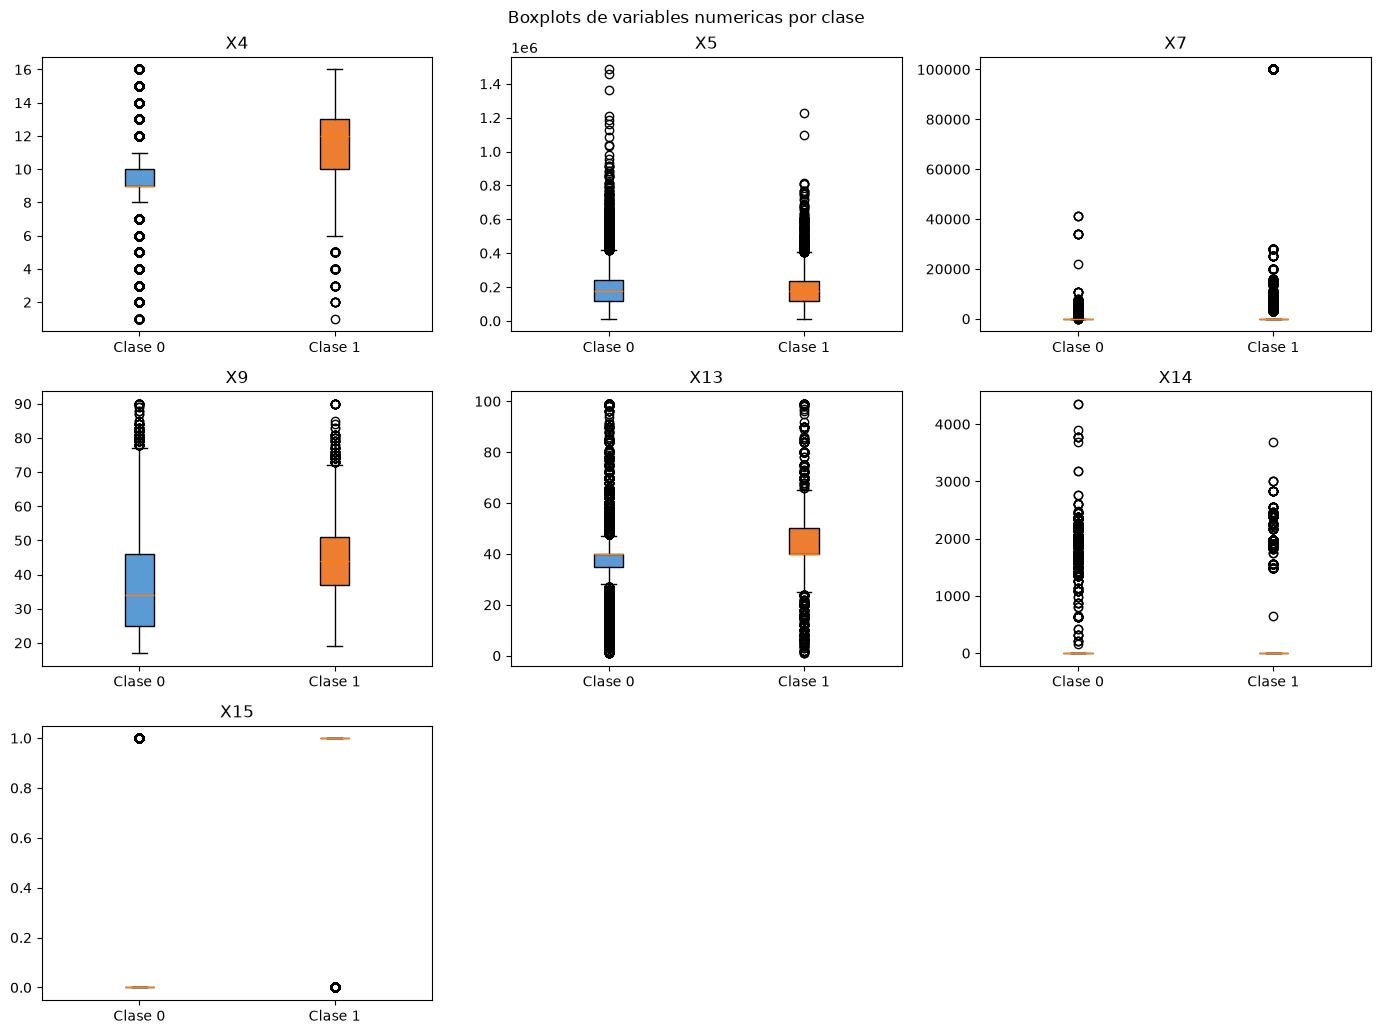

In [20]:
# ============================================================
# EDA-7. Boxplots de numericas por clase
# ============================================================
ncols = 3
nrows = (len(eda_numeric) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(eda_numeric):
    ax = axes[i]
    data_bp = [
        train_df[train_df[target_col] == 0][col].dropna(),
        train_df[train_df[target_col] == 1][col].dropna(),
    ]
    bp = ax.boxplot(
        data_bp,
        tick_labels=["Clase 0", "Clase 1"],
        patch_artist=True,
    )
    for patch, color in zip(bp["boxes"], ["#5B9BD5", "#ED7D31"]):
        patch.set_facecolor(color)
    ax.set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots de variables numericas por clase")
plt.tight_layout()
plt.show()

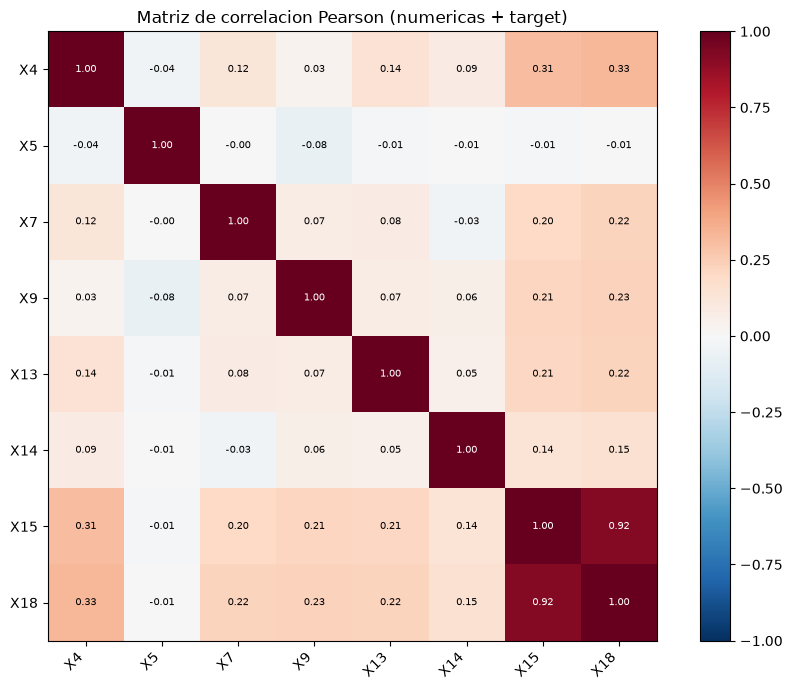

Correlacion |Pearson| con el target:


,|pearson|
X15,0.9207
X4,0.3320
X9,0.2307
X13,0.2248
X7,0.2212
X14,0.1510
X5,0.0076


In [21]:
# ============================================================
# EDA-8. Matriz de correlacion (numericas + target)
# ============================================================
num_with_target = eda_numeric + [target_col]
corr_full = train_df[num_with_target].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_full.values, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_with_target)))
ax.set_yticks(range(len(num_with_target)))
ax.set_xticklabels(num_with_target, rotation=45, ha="right")
ax.set_yticklabels(num_with_target)

for i in range(len(num_with_target)):
    for j in range(len(num_with_target)):
        v = corr_full.values[i, j]
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if abs(v) > 0.5 else "black",
        )

ax.set_title("Matriz de correlacion Pearson (numericas + target)")
plt.tight_layout()
plt.show()

corr_with_target = (
    corr_full[target_col].drop(target_col).abs().sort_values(ascending=False)
)
print("Correlacion |Pearson| con el target:")
display(corr_with_target.to_frame("|pearson|").round(4))

### Fase 4 — Anomalías: outliers, cardinalidad y variables casi constantes


In [22]:
# ============================================================
# EDA-9. Variables casi constantes y de alta cardinalidad
# ============================================================
n_train = len(train_df)
feat_cols = [c for c in train_df.columns if c != target_col]

anom_rows = []
for col in feat_cols:
    n_unique = train_df[col].nunique(dropna=True)
    vc = train_df[col].value_counts(dropna=True)
    top_freq = vc.iloc[0] / n_train if len(vc) > 0 else 1.0
    flags = []
    if top_freq > 0.95:
        flags.append("casi constante")
    if n_unique > 1000:
        flags.append("alta cardinalidad")
    if n_unique == 1:
        flags.append("constante absoluta")
    anom_rows.append(
        {
            "feature": col,
            "n_unique": n_unique,
            "top_freq_pct": round(top_freq * 100, 2),
            "alertas": ", ".join(flags) if flags else "-",
        }
    )

anom_df = pd.DataFrame(anom_rows).sort_values("n_unique", ascending=False)
print("Variables con posibles anomalias estructurales:")
display(anom_df)

Variables con posibles anomalias estructurales:


,feature,n_unique,top_freq_pct,alertas
4,X5,24612,0.04,alta cardinalidad
6,X7,122,91.83,-
13,X14,99,95.21,casi constante
12,X13,95,46.52,-
8,X9,73,2.72,-
0,X1,41,89.83,-
2,X3,16,32.48,-
3,X4,16,32.48,-
15,X16,14,12.66,-
1,X2,8,69.37,-


In [23]:
# ============================================================
# EDA-10. Outliers numericos (metodo IQR x3)
# ============================================================
outlier_rows = []
for col in eda_numeric:
    s = train_df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = int(((s < lower) | (s > upper)).sum())
    outlier_rows.append(
        {
            "feature": col,
            "min": round(float(s.min()), 2),
            "max": round(float(s.max()), 2),
            "Q1": round(float(Q1), 2),
            "Q3": round(float(Q3), 2),
            "n_outliers_IQR3x": n_out,
            "pct_outliers": round(n_out / len(s) * 100, 2),
        }
    )

outlier_df = pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False)
display(outlier_df)

,feature,min,max,Q1,Q3,n_outliers_IQR3x,pct_outliers
4,X13,1.0,99.0,40.0,45.0,5309,13.59
2,X7,0.0,99999.0,0.0,0.0,3194,8.17
5,X14,0.0,4356.0,0.0,0.0,1872,4.79
1,X5,12285.0,1484705.0,117700.0,237466.0,175,0.45
0,X4,1.0,16.0,9.0,12.0,0,0.00
3,X9,17.0,90.0,28.0,48.0,0,0.00
6,X15,0.0,1.0,0.0,1.0,0,0.00


### Fase 5 — Insights y ranking preliminar de sospecha

> **Criterios de sospecha de leakage:**
>
> - `|pearson| >= 0.5` con el target (correlación directa inusualmente alta).
> - `rate_range >= 0.7` en categóricas (una o pocas categorías separan casi perfectamente las clases).
> - Alta cardinalidad (`n_unique > 5000`) — puede actuar como ID y memorizar en lugar de generalizar.
> - Variables con distribución bifurcada por clase muy marcada en los histogramas (Fase 2).
>
> Las métricas formales de correlación, mutual information e importancia por permutación se calculan
> en las Secciones 9–12 a continuación.


In [24]:
# ============================================================
# EDA-11. Ranking preliminar de sospecha
# ============================================================
import warnings

warnings.filterwarnings("ignore")

feat_cols = [c for c in train_df.columns if c != target_col]
suspicion_rows = []

for col in feat_cols:
    s = train_df[col]
    n_unique = s.nunique()
    missing_pct = s.isnull().mean() * 100

    if col in eda_numeric:
        pearson = abs(
            np.corrcoef(
                pd.to_numeric(s, errors="coerce").fillna(s.median()),
                train_df[target_col],
            )[0, 1]
        )
    else:
        pearson = None

    if col in eda_categoric:
        rates = train_df.groupby(col, dropna=False)[target_col].mean()
        rate_range = float(rates.max() - rates.min())
    else:
        rate_range = None

    flags = []
    if pearson is not None and pearson > 0.5:
        flags.append(f"|r|={pearson:.2f} ALTO")
    if rate_range is not None and rate_range > 0.7:
        flags.append(f"rate_range={rate_range:.2f} ALTO")
    if n_unique > 5000:
        flags.append("alta cardinalidad")
    if missing_pct > 5:
        flags.append(f"missing={missing_pct:.1f}%")

    suspicion_rows.append(
        {
            "feature": col,
            "dtype": str(train_df[col].dtype),
            "n_unique": n_unique,
            "|pearson|": round(pearson, 4) if pearson is not None else None,
            "rate_range": round(rate_range, 4) if rate_range is not None else None,
            "alertas": " | ".join(flags) if flags else "-",
        }
    )

suspicion_df = pd.DataFrame(suspicion_rows)
has_alert = suspicion_df["alertas"] != "-"
suspicion_df = pd.concat(
    [
        suspicion_df[has_alert].sort_values(
            "|pearson|", ascending=False, na_position="last"
        ),
        suspicion_df[~has_alert],
    ]
)

print("=== Ranking preliminar de sospecha (pre-auditoria formal) ===")
display(suspicion_df)

=== Ranking preliminar de sospecha (pre-auditoria formal) ===


,feature,dtype,n_unique,|pearson|,rate_range,alertas
14,X15,int64,2,0.9207,NaN,|r|=0.92 ALTO
4,X5,int64,24612,0.0076,NaN,alta cardinalidad
1,X2,str,8,NaN,0.5492,missing=5.7%
2,X3,str,16,NaN,0.7197,rate_range=0.72 ALTO
9,X10,str,2,NaN,0.7619,rate_range=0.76 ALTO
15,X16,str,14,NaN,0.4710,missing=5.7%
0,X1,str,41,NaN,0.4516,-
3,X4,int64,16,0.3320,NaN,-
5,X6,str,5,NaN,0.1584,-
6,X7,int64,122,0.2212,NaN,-


### Detección de leakage — AUC univariado por variable

Para cada variable se entrena un clasificador mínimo usando **sólo esa feature**.
Un AUC ≥ 0.90 de forma individual es señal fuerte de **leakage** o de que la variable
codifica directamente el target (o es una transformación de él).

| Umbral AUC  | Interpretación            |
| ----------- | ------------------------- |
| ≥ 0.99      | Leakage casi seguro       |
| 0.90 – 0.99 | Muy sospechosa            |
| 0.70 – 0.90 | Predictiva pero plausible |
| < 0.70      | Normal                    |


  X1      AUC=0.5096  -
  X2      AUC=0.5095  -
  X3      AUC=0.5192  -
  X4      AUC=0.7156  predictiva (normal)
  X5      AUC=0.5051  -
  X6      AUC=0.5320  -
  X7      AUC=0.5861  -
  X8      AUC=0.6488  -
  X9      AUC=0.6823  -
  X10     AUC=0.9198  MUY SOSPECHOSA
  X11     AUC=0.4978  -
  X12     AUC=0.7154  predictiva (normal)
  X13     AUC=0.6714  -
  X14     AUC=0.5337  -
  X15     AUC=0.9695  MUY SOSPECHOSA
  X16     AUC=0.4954  -
  X17     AUC=0.6173  -

=== Ranking de AUC univariado ===


,feature,auc_univariado,alerta
14,X15,0.9695,MUY SOSPECHOSA
9,X10,0.9198,MUY SOSPECHOSA
3,X4,0.7156,predictiva (normal)
11,X12,0.7154,predictiva (normal)
8,X9,0.6823,-
12,X13,0.6714,-
7,X8,0.6488,-
16,X17,0.6173,-
6,X7,0.5861,-
13,X14,0.5337,-


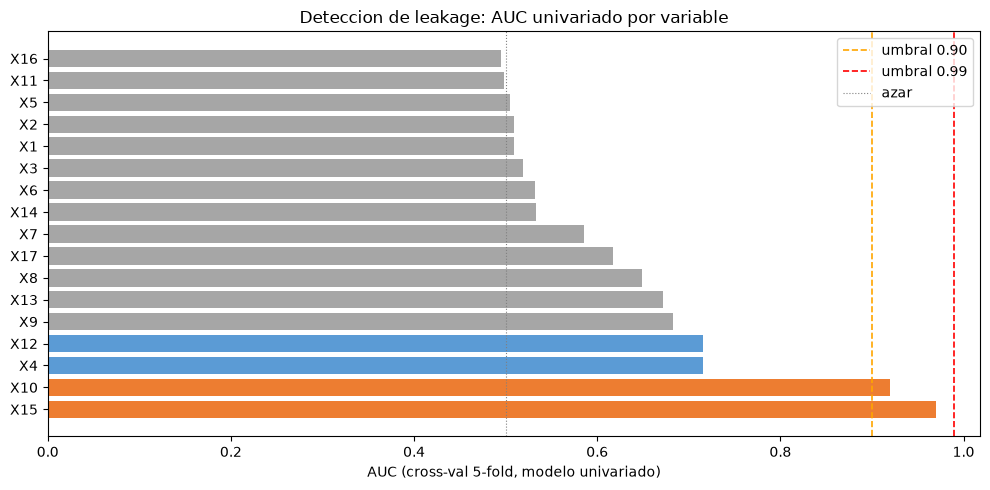

Variables SOSPECHOSAS de leakage:


,feature,auc_univariado,alerta
14,X15,0.9695,MUY SOSPECHOSA
9,X10,0.9198,MUY SOSPECHOSA


In [26]:
# ============================================================
# EDA-12. Deteccion de leakage: AUC univariado por variable
# ============================================================
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings("ignore")

TARGET = target_col
y_eda = train_df[TARGET].values
cv_eda = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

leakage_rows = []

for col in train_df.columns:
    if col == TARGET:
        continue

    s = train_df[col].copy()

    # Codificar: categóricas → LabelEncoder, numéricas → usar directo
    if col in eda_numeric:
        s_numeric = pd.to_numeric(s, errors="coerce")
        s = s_numeric.fillna(s_numeric.median()).to_numpy()
    else:
        le = LabelEncoder()
        s = le.fit_transform(s.astype(str).fillna("__missing__"))

    X_uni = s.reshape(-1, 1)

    # AUC con cross-val (LogReg de 1 sola variable)
    try:
        proba = cross_val_predict(
            LogisticRegression(max_iter=300, solver="lbfgs"),
            X_uni,
            y_eda,
            cv=cv_eda,
            method="predict_proba",
        )[:, 1]
        auc = roc_auc_score(y_eda, proba)
    except Exception as e:
        auc = float("nan")

    # Determinar alerta
    if auc >= 0.99:
        alerta = "LEAKAGE CASI SEGURO"
    elif auc >= 0.90:
        alerta = "MUY SOSPECHOSA"
    elif auc >= 0.70:
        alerta = "predictiva (normal)"
    else:
        alerta = "-"

    leakage_rows.append(
        {"feature": col, "auc_univariado": round(auc, 4), "alerta": alerta}
    )
    print(f"  {col:6s}  AUC={auc:.4f}  {alerta}")

leakage_df = pd.DataFrame(leakage_rows).sort_values("auc_univariado", ascending=False)

print("\n=== Ranking de AUC univariado ===")
display(leakage_df)

# Grafico
fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    (
        "#C00000"
        if a == "LEAKAGE CASI SEGURO"
        else (
            "#ED7D31"
            if a == "MUY SOSPECHOSA"
            else "#5B9BD5" if a == "predictiva (normal)" else "#A6A6A6"
        )
    )
    for a in leakage_df["alerta"]
]
ax.barh(leakage_df["feature"], leakage_df["auc_univariado"], color=colors)
ax.axvline(0.90, color="orange", linestyle="--", linewidth=1.2, label="umbral 0.90")
ax.axvline(0.99, color="red", linestyle="--", linewidth=1.2, label="umbral 0.99")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=0.8, label="azar")
ax.set_xlabel("AUC (cross-val 5-fold, modelo univariado)")
ax.set_title("Deteccion de leakage: AUC univariado por variable")
ax.legend()
plt.tight_layout()
plt.show()

sospechosas = leakage_df[
    leakage_df["alerta"].isin(["LEAKAGE CASI SEGURO", "MUY SOSPECHOSA"])
]
if len(sospechosas):
    print("Variables SOSPECHOSAS de leakage:")
    display(sospechosas)
else:
    print("Ninguna variable supera el umbral de sospecha.")

In [27]:
# ============================================================
# 4. Separar X/y
# ============================================================
X_train = train_df.drop(columns=[target_col]).copy()
y_train = train_df[target_col].copy()

X_test = test_df.drop(columns=[target_col]).copy()
y_test = test_df[target_col].copy()

In [28]:
# ============================================================
# 5. Auditoría rápida de columnas
# ============================================================
summary = pd.DataFrame(
    {
        "dtype": X_train.dtypes.astype(str),
        "n_missing": X_train.isnull().sum(),
        "pct_missing": (X_train.isnull().mean() * 100).round(2),
        "n_unique": X_train.nunique(),
    }
).sort_values(["dtype", "n_unique"])

display(summary.head(30))

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numéricas:", len(numeric_cols))
print("Categóricas:", len(categorical_cols))

,dtype,n_missing,pct_missing,n_unique
X15,int64,0,0.00,2
X4,int64,0,0.00,16
X9,int64,0,0.00,73
X13,int64,0,0.00,95
X14,int64,0,0.00,99
X7,int64,0,0.00,122
X5,int64,0,0.00,24612
X10,str,0,0.00,2
X17,str,0,0.00,2
X11,str,0,0.00,4


Numéricas: 7
Categóricas: 10


In [29]:
# ============================================================
# 6. Preprocesamiento
# ============================================================
numeric_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

## Modelo base

Este baseline usa **todas las variables**. Si el dataset contiene leakage, aquí suelen aparecer scores inflados.


In [30]:
# ============================================================
# 7. Modelo base
# ============================================================
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["roc_auc", "accuracy", "f1"],
    n_jobs=-1,
    return_train_score=False,
)

baseline_cv_summary = pd.DataFrame(cv_results).agg(["mean", "std"]).T
display(baseline_cv_summary)

,mean,std
fit_time,7.872177,0.027472
score_time,0.611743,0.029875
test_roc_auc,0.998084,0.000505
test_accuracy,0.985821,0.001017
test_f1,0.970076,0.002214


In [31]:
# ============================================================
# 8. Ajuste final y evaluación en test
# ============================================================
baseline_model.fit(X_train, y_train)

test_pred = baseline_model.predict(X_test)
test_prob = baseline_model.predict_proba(X_test)[:, 1]

metrics = {
    "roc_auc": roc_auc_score(y_test, test_prob),
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
}

print("=== Baseline en test ===")
for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification report:")
print(classification_report(y_test, test_pred, zero_division=0))

=== Baseline en test ===
roc_auc   : 0.9977
accuracy  : 0.9851
precision : 0.9765
recall    : 0.9607
f1        : 0.9685

Matriz de confusión:
[[7377   54]
 [  92 2246]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7431
           1       0.98      0.96      0.97      2338

    accuracy                           0.99      9769
   macro avg       0.98      0.98      0.98      9769
weighted avg       0.99      0.99      0.99      9769



## Auditoría de correlación y asociación

Aquí buscamos señales de variables problemáticas:

- variables **demasiado correlacionadas** con el target,
- variables con **mutual information** anormalmente alta,
- variables con **importancia por permutación** excesiva,
- variables redundantes entre sí,
- columnas casi constantes o de alta cardinalidad sospechosa.


In [32]:
# ============================================================
# 9. Correlación de variables numéricas con target
# ============================================================
corr_rows = []

for col in numeric_cols:
    s = pd.to_numeric(X_train[col], errors="coerce")
    valid = ~(s.isna() | pd.isna(y_train))
    if valid.sum() > 3:
        pearson = np.corrcoef(s[valid], y_train[valid])[0, 1]
        spearman = pd.Series(s[valid]).corr(
            pd.Series(y_train[valid]), method="spearman"
        )
    else:
        pearson, spearman = np.nan, np.nan

    corr_rows.append(
        {
            "feature": col,
            "pearson_with_target": pearson,
            "spearman_with_target": spearman,
            "abs_max_corr": np.nanmax(
                [
                    abs(pearson) if pd.notna(pearson) else np.nan,
                    abs(spearman) if pd.notna(spearman) else np.nan,
                ]
            ),
        }
    )

corr_df = pd.DataFrame(corr_rows).sort_values("abs_max_corr", ascending=False)
display(corr_df.head(20))

,feature,pearson_with_target,spearman_with_target,abs_max_corr
6,X15,0.920696,0.920696,0.920696
0,X4,0.332008,0.326847,0.332008
2,X7,0.221237,0.274547,0.274547
3,X9,0.230738,0.269505,0.269505
4,X13,0.224826,0.267171,0.267171
5,X14,0.151010,0.141746,0.151010
1,X5,-0.007626,-0.008221,0.008221


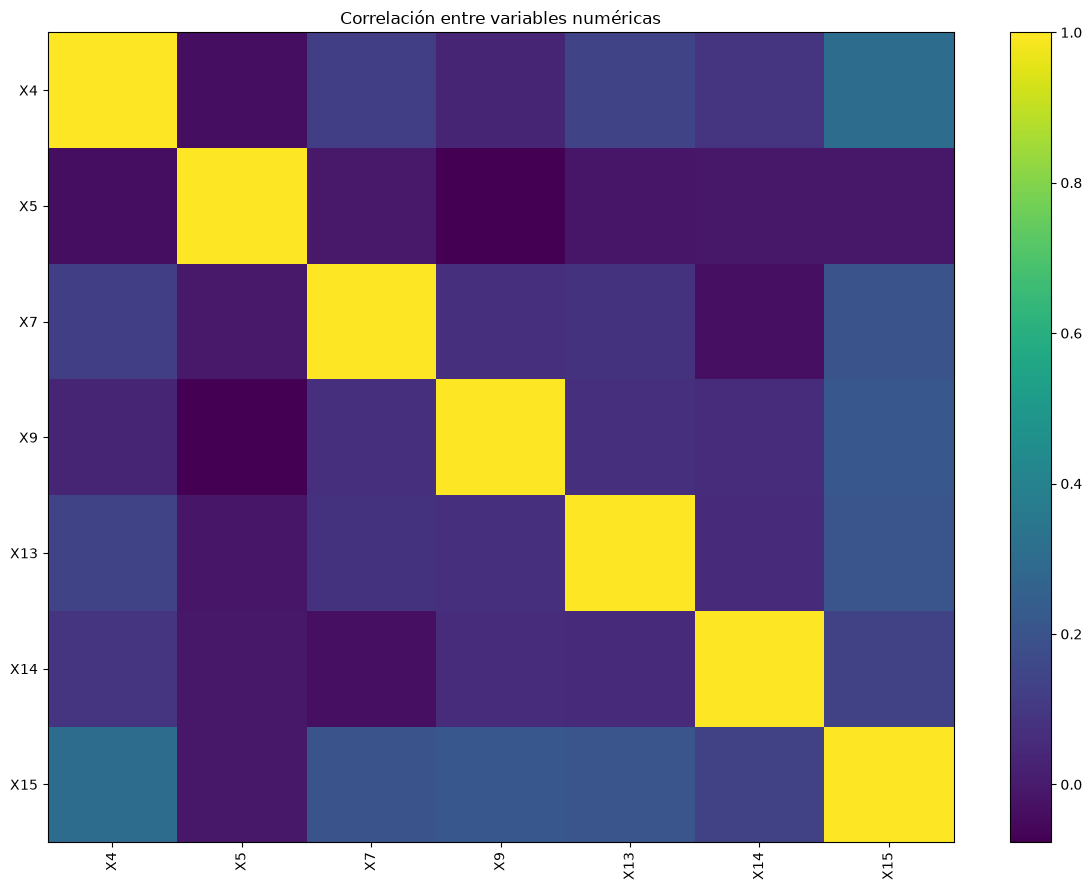

Pares con |corr| >= 0.85:


,feature_1,feature_2,corr


In [33]:
# ============================================================
# 10. Heatmap de correlación entre variables numéricas
# ============================================================
if len(numeric_cols) > 1:
    corr_matrix = X_train[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 9))
    plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.title("Correlación entre variables numéricas")
    plt.tight_layout()
    plt.show()

    high_pairs = []
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) >= 0.85:
                high_pairs.append((numeric_cols[i], numeric_cols[j], val))

    high_pairs_df = pd.DataFrame(high_pairs, columns=["feature_1", "feature_2", "corr"])
    print("Pares con |corr| >= 0.85:")
    display(
        high_pairs_df.sort_values("corr", key=lambda s: s.abs(), ascending=False).head(
            20
        )
    )

In [36]:
# ============================================================
# 11. Mutual information feature-target
# ============================================================
X_mi = X_train.copy()

for c in X_mi.columns:
    if X_mi[c].dtype == "O":
        X_mi[c] = X_mi[c].astype(str).fillna("missing")
        X_mi[c] = pd.factorize(X_mi[c])[0]
    else:
        X_mi[c] = pd.to_numeric(X_mi[c], errors="coerce")
        X_mi[c] = X_mi[c].fillna(X_mi[c].median())

discrete_mask = [col not in numeric_cols for col in X_mi.columns]

# Rebuild the encoded matrix using the known numeric columns.
# This avoids NaN values caused by dtype detection of pandas string columns.
for c in X_mi.columns:
    if c in numeric_cols:
        X_mi[c] = pd.to_numeric(X_train[c], errors="coerce")
        X_mi[c] = X_mi[c].replace([np.inf, -np.inf], np.nan)
        X_mi[c] = X_mi[c].fillna(X_mi[c].median()).fillna(0)
    else:
        values = X_train[c].astype("string").fillna("__missing__")
        X_mi[c] = pd.factorize(values)[0]

mi_scores = mutual_info_classif(
    X_mi.astype(float),
    y_train,
    discrete_features=discrete_mask,
    random_state=42,
)

mi_df = pd.DataFrame(
    {"feature": X_mi.columns, "mutual_information": mi_scores}
).sort_values("mutual_information", ascending=False)

display(mi_df.head(20))

,feature,mutual_information
14,X15,0.435028
9,X10,0.319109
11,X12,0.115828
7,X8,0.110525
6,X7,0.081991
8,X9,0.066168
3,X4,0.064613
15,X16,0.063440
2,X3,0.063378
12,X13,0.039467


In [35]:
# ============================================================
# 12. Importancia por permutación
# ============================================================
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)

rf_model.fit(X_train, y_train)

perm = permutation_importance(
    rf_model, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "permutation_importance_mean": perm.importances_mean,
        "permutation_importance_std": perm.importances_std,
    }
).sort_values("permutation_importance_mean", ascending=False)

display(perm_df.head(20))

,feature,permutation_importance_mean,permutation_importance_std
14,X15,7.151795e-02,0.001358
9,X10,1.853622e-02,0.000802
6,X7,1.039653e-03,0.000102
7,X8,3.874655e-04,0.000156
8,X9,2.675714e-04,0.000057
15,X16,9.721027e-05,0.000078
10,X11,9.706062e-05,0.000117
2,X3,3.478250e-05,0.000137
16,X17,2.887702e-05,0.000039
12,X13,2.571131e-05,0.000103


In [ ]:
# ============================================================
# 13. Ranking combinado de sospecha
# ============================================================

## Modelo auditado

Seleccione aquí, manualmente, las variables que parecen sospechosas según el análisis anterior.


In [37]:
# ============================================================
# 14. Modelo auditado: excluir variables sospechosas
# ============================================================
suspect_features_to_remove = [
    "X10",  # Leakage (Tasa de clase 1 muy alta vs otras, gran mutual information)
    "X15",  # Leakage (Correlacion de Pearson de 0.92, AUC > 0.96)
    "X11",  # Irrelevante/Ruido (Tasa de clase 1 constante, sin poder predictivo)
]

X_train_clean = X_train.drop(columns=suspect_features_to_remove, errors="ignore").copy()
X_test_clean = X_test.drop(columns=suspect_features_to_remove, errors="ignore").copy()

numeric_cols_clean = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_clean = [
    c for c in X_train_clean.columns if c not in numeric_cols_clean
]

preprocessor_clean = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_clean),
        ("cat", categorical_transformer, categorical_cols_clean),
    ]
)

audited_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_clean),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)

audited_cv_results = cross_validate(
    audited_model,
    X_train_clean,
    y_train,
    cv=cv,
    scoring=["roc_auc", "accuracy", "f1"],
    n_jobs=-1,
    return_train_score=False,
)

audited_cv_summary = pd.DataFrame(audited_cv_results).agg(["mean", "std"]).T
print("=== CV modelo auditado ===")
display(audited_cv_summary)

audited_model.fit(X_train_clean, y_train)
audited_pred = audited_model.predict(X_test_clean)
audited_prob = audited_model.predict_proba(X_test_clean)[:, 1]

audited_metrics = {
    "roc_auc": roc_auc_score(y_test, audited_prob),
    "accuracy": accuracy_score(y_test, audited_pred),
    "precision": precision_score(y_test, audited_pred, zero_division=0),
    "recall": recall_score(y_test, audited_pred, zero_division=0),
    "f1": f1_score(y_test, audited_pred, zero_division=0),
}

print("=== Test modelo auditado ===")
for k, v in audited_metrics.items():
    print(f"{k:10s}: {v:.4f}")

comparison = pd.DataFrame(
    {"baseline_all_features": metrics, "audited_without_suspects": audited_metrics}
)
display(comparison)

=== CV modelo auditado ===


,mean,std
fit_time,10.170662,0.490513
score_time,1.239015,0.421443
test_roc_auc,0.901080,0.004855
test_accuracy,0.852711,0.005172
test_f1,0.667369,0.012401


=== Test modelo auditado ===
roc_auc   : 0.9047
accuracy  : 0.8580
precision : 0.7395
recall    : 0.6279
f1        : 0.6792


,baseline_all_features,audited_without_suspects
roc_auc,0.997668,0.904740
accuracy,0.985055,0.858020
precision,0.976522,0.739547
recall,0.960650,0.627887
f1,0.968521,0.679158


## Análisis final

Compare el modelo base con el modelo auditado.

Explique:

- ¿Qué variables decidió remover?
- ¿Qué evidencia sustenta esa decisión?
- ¿Cómo cambió el desempeño?
- ¿Qué riesgos tendría esto en producción?


## Experimento Final: Inversión de Targets

Para comprobar empíricamente la naturaleza de las variables detectadas, ejecutaremos el mismo `RandomForestClassifier`, pero **cambiando el target**:

1. **Predeciremos `X15` (Leakage)** usando todas las demás variables (incluyendo `X18`). Si `X15` es leakage directo, el modelo debería poder predecirlo con una precisión casi perfecta.
2. **Predeciremos `X11` (Ruido)** usando todas las demás variables. Al ser puro ruido sin relación estructurada, el modelo será incapaz de predecirlo y su precisión colapsará.


In [ ]:
# ============================================================
# 15. Prediciendo X15 (Variable de Leakage)
# ============================================================
target_15 = "X15"

X_train_15 = train_df.drop(columns=[target_15])
y_train_15 = train_df[target_15]

X_test_15 = test_df.drop(columns=[target_15])
y_test_15 = test_df[target_15]

# Identificar tipos de columnas dinámicamente
num_15 = X_train_15.select_dtypes(include=[np.number]).columns.tolist()
cat_15 = [c for c in X_train_15.columns if c not in num_15]

# Preprocesador específico para este experimento
prep_15 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_15),
        ("cat", categorical_transformer, cat_15),
    ]
)

model_15 = Pipeline(
    steps=[
        ("preprocessor", prep_15),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)

model_15.fit(X_train_15, y_train_15)
pred_15 = model_15.predict(X_test_15)
prob_15 = model_15.predict_proba(X_test_15)[:, 1]

print("=== Resultados prediciendo X15 (Leakage) ===")
print(f"Accuracy : {accuracy_score(y_test_15, pred_15):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test_15, prob_15):.4f}")
print(f"F1 Score : {f1_score(y_test_15, pred_15, zero_division=0):.4f}")

=== Resultados prediciendo X15 (Leakage) ===
Accuracy : 0.9709
ROC AUC  : 0.9525
F1 Score : 0.9411


In [ ]:
# ============================================================
# 16. Prediciendo X11 (Variable de Ruido/Irrelevante)
# ============================================================
target_11 = "X11"

X_train_11 = train_df.drop(columns=[target_11])
y_train_11 = train_df[target_11]

X_test_11 = test_df.drop(columns=[target_11])
y_test_11 = test_df[target_11]

num_11 = X_train_11.select_dtypes(include=[np.number]).columns.tolist()
cat_11 = [c for c in X_train_11.columns if c not in num_11]

prep_11 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_11),
        ("cat", categorical_transformer, cat_11),
    ]
)

model_11 = Pipeline(
    steps=[
        ("preprocessor", prep_11),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)

model_11.fit(X_train_11, y_train_11)
pred_11 = model_11.predict(X_test_11)
prob_11 = model_11.predict_proba(X_test_11)  # Multiclase

print("=== Resultados prediciendo X11 (Ruido) ===")
print(f"Accuracy      : {accuracy_score(y_test_11, pred_11):.4f}")
try:
    # ROC AUC macro por ser multiclase
    auc_11 = roc_auc_score(y_test_11, prob_11, multi_class="ovr", average="macro")
    print(f"ROC AUC (OVR) : {auc_11:.4f}")
except Exception as e:
    print("No se pudo calcular ROC AUC multiclase.")

print(
    f"F1 (Macro)    : {f1_score(y_test_11, pred_11, average='macro', zero_division=0):.4f}"
)

=== Resultados prediciendo X11 (Ruido) ===
Accuracy      : 0.2575
ROC AUC (OVR) : 0.5085
F1 (Macro)    : 0.2575


### Conclusión del Experimento

- **Alta precisión al predecir X15**: Confirma que el Leakage es bidireccional; si `X15` nos dice casi perfectamente quién es `X18`, usar el target `X18` para predecir `X15` revela que son virtualmente la misma información codificada.
- **Baja precisión al predecir X11**: Confirma que `X11` es puro ruido estocástico; el resto de variables del dataset (incluyendo el target real) son incapaces de descifrar un patrón, por lo que el modelo colapsa a adivinar la clase mayoritaria.
